In [4]:
import pandas as pd
import numpy as np
from scipy.stats import t
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [5]:
# Calling Everything

df = pd.read_csv('data\pressure_washing_cleaned.csv')
lr = LinearRegression()
scaler = StandardScaler()
mor = MultiOutputRegressor(lr)

pl = make_pipeline(scaler, mor)

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\sense\AppData\Local\Temp\ipykernel_18624\2126456735.py:3: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv('data\pressure_washing_cleaned.csv')


Data Processing

In [149]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
x = df.drop(columns=['bleach_cost', 'gas_cost'])

y = df[['bleach_cost', 'gas_cost']].reset_index(drop=True)

Running the model

In [7]:
mor.fit(x, y) # How every other variable predicts gas and bleach cost
# y_pred = mor.predict(x_test)
# mean_squared_error(y_test, y_pred)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,LinearRegression()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model evaluation making Y hat


Important Metrics

In [ ]:
# Isolating each target 0 is bleach 1 is gas

est = pl.named_steps['multioutputregressor'].estimators_
coef_one = est[0].coef_
coef_two = est[1].coef_

intercept_one = est[0].intercept_
intercept_two = est[1].intercept_

In [9]:
y_hat_bleach = coef_one[0]*x.iloc[:,0] + coef_one[1]*x.iloc[:,1] + coef_one[2]*x.iloc[:,2] + intercept_one
y_one = y['bleach_cost']


# Making dataframe of the regression line and the mean line
y_hat = pd.DataFrame(y_hat_bleach)
mean_line = pd.DataFrame(np.mean(y_one), index=y_one.index, columns=['y_mean'])

# Rating our regression line
mean_squared_error(y_one, mean_line)
mean_squared_error(y_one, y_hat)

y_table = pd.concat(objs=[y_one, y_hat, mean_line], axis=1)

y_table.columns = ['y', 'y_regressed', 'y_mean']

# Calculating r^2 score of all the points instead of test points
1 - np.sum((y_table['y'] - y_table['y_regressed'])**2) / np.sum((y_table['y'] - y_table['y_mean'])**2) # 87% r2 score 

np.float64(0.977659020894007)

Using our model

In [101]:
coef_one[2]
intercept_one

np.float64(-0.34205451251246544)

In [103]:
# input data
amount = 140
sq_feet = 200
duration = 1.5

y_prediction_bleach = coef_one[0]*amount + coef_one[1]*sq_feet + coef_one[2]*duration + intercept_one
y_prediction_bleach

np.float64(6.218496154895662)

In [ ]:
coef_one[0]*amount + coef_one[1]*sq_feet + coef_one[2]*duration + intercept_one


In [11]:
MSE = mean_squared_error(y_one, y_hat) # How good does the line fit Y

p = x.shape[1] + 1
n = x.shape[0]
dfyx = n - p # degrees of freedom

alpha = .025 # 95% CI
critical_value = np.abs(t.ppf(alpha, dfyx)) # for final calculation

intercept_frame = pd.DataFrame(data=intercept_one, columns=['intercept'], index=x.index)
x_matrix = pd.concat(objs=[x, intercept_frame], axis=1) # adding intercept to x values

# multi output standard error calculation
xtx = np.linalg.inv(x_matrix.T @ x_matrix)
cov_beta = xtx* MSE
np.diag(cov_beta)
x_calc = np.array([1, coef_one[0], coef_one[1], coef_one[2]])
critical_value*np.sqrt(x_calc.T@cov_beta@x_calc)

interval = critical_value*np.sqrt(x_calc.T@cov_beta@x_calc) # 95% CI

In [42]:
# lower limit (many jobs usually take around 2 hours minimum hence the statement)
if y_prediction_bleach > 10: # I usually use one jug reguardless 
    y_pred_calc = y_prediction_bleach - interval
    lower_bound = np.round(y_pred_calc, 0).round()
else:
    lower_bound = y_prediction_bleach.round()


higher_bound = (y_prediction_bleach + interval).round() // 1

# result
print(f'You will spend between {lower_bound} dollar(s) and {higher_bound} dollars on bleach')

You will spend between 6.0 dollar(s) and 10.0 dollars on bleach


Doing the same for gas

In [58]:
y_hat_gas = coef_two[0]*x.iloc[:,0] + coef_two[1]*x.iloc[:,1] + coef_two[2]*x.iloc[:,2] + intercept_one
y_two = y['gas_cost']


# Making dataframe of the regression line and the mean line
y_hat_two = pd.DataFrame(y_hat_gas)
mean_line_two = pd.DataFrame(np.mean(y_two), index=y_two.index, columns=['y_mean'])

# Rating our regression line
mean_squared_error(y_two, mean_line_two)
mean_squared_error(y_two, y_hat_two)

y_table_two = pd.concat(objs=[y_two, y_hat_two, mean_line_two], axis=1)

y_table_two.columns = ['y', 'y_regressed', 'y_mean']

# Calculating r^2 score of all the points instead of test points
1 - np.sum((y_table_two['y'] - y_table_two['y_regressed'])**2) / np.sum((y_table_two['y'] - y_table_two['y_mean'])**2) # 63% r2 score 

np.float64(0.6309527934315096)

Using our model

In [106]:
# input data
amount = 140
sq_feet = 200
duration = 1.5

y_prediction_gas = coef_two[0]*amount + coef_two[1]*sq_feet + coef_two[2]*duration + intercept_one
y_prediction_gas

np.float64(3.3487554139138407)

In [60]:
MSE = mean_squared_error(y_two, y_hat_two) # How good does the line fit Y

p = x.shape[1] + 1
n = x.shape[0]
dfyx = n - p # degrees of freedom

alpha = .025 # 95% CI
critical_value = np.abs(t.ppf(alpha, dfyx)) # for final calculation

intercept_frame = pd.DataFrame(data=intercept_one, columns=['intercept'], index=x.index)
x_matrix = pd.concat(objs=[x, intercept_frame], axis=1) # adding intercept to x values

# multi output standard error calculation
xtx = np.linalg.inv(x_matrix.T @ x_matrix)
cov_beta = xtx* MSE
np.diag(cov_beta)
x_calc = np.array([1, coef_one[0], coef_one[1], coef_one[2]])
critical_value*np.sqrt(x_calc.T@cov_beta@x_calc)

interval = critical_value*np.sqrt(x_calc.T@cov_beta@x_calc) # 95% CI

In [61]:
# lower limit (many jobs usually take around 2 hours minimum hence the statement)
if y_prediction_bleach > 7: # I usually use two gallons reguardless 
    y_pred_calc = y_prediction_gas - interval
    lower_bound = np.round(y_pred_calc, 0).round()
else:
    lower_bound = y_prediction_bleach.round()


higher_bound = (y_prediction_gas + interval).round() // 1

# result
print(f'You will spend between {lower_bound} dollar(s) and {higher_bound} dollars on gas')

You will spend between 6.0 dollar(s) and 10.0 dollars on gas


Looking at the data

In [13]:
intercept = intercept_one
coef = coef_one

X_line = np.linspace(x.min(), x.max(), 100)

y_line = intercept + coef*X_line
y_mean = np.mean(y)

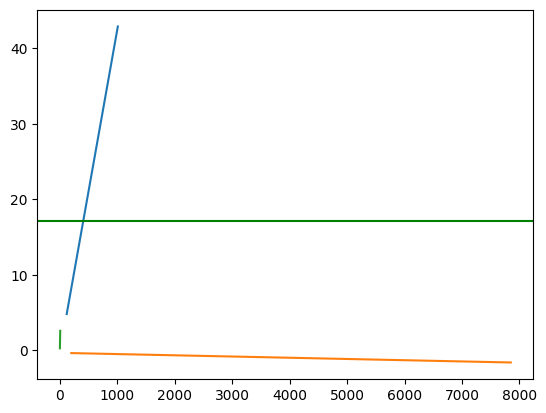

In [43]:
# plt.scatter(x, y, color='red') # scatter points
plt.plot(X_line, y_line) # regression line
plt.axhline(y=y_mean, color='green') # mean line

Model Improvement

In [ ]:
cross_val_score(X=x, y=y, estimator=mor, scoring='neg_mean_absolute_error', cv=10)

array([-1.53020991, -1.16086519, -1.50214538, -1.95160337, -1.81375005,
       -2.51593205, -1.62028124, -1.71137916, -1.90461054, -0.91602335])

In [ ]:
#for cross validation
x = x.reset_index()
x = x.drop(columns='index')

y = y.reset_index()
y = y.drop(columns='index')